<a href="https://colab.research.google.com/github/anthu-Cyril/Predictive-Maintenance-Project-/blob/main/Student_Social_media__Addiction_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Social Media Addictions Analysis

## Introduction to the Social Media Addiction Analysis Dataset

This dataset contains information about students and their social media usage patterns, aiming to explore the factors related to social media addiction. The dataset includes various attributes such as age, gender, academic level, country, average daily social media usage hours, most used platform, the perceived impact on academic performance, sleep hours, mental health score, relationship status, conflicts over social media, and an 'Addicted_Score'.

The analysis of this dataset can provide insights into:
- The demographics and characteristics of students who may be at risk of social media addiction.
- The relationship between social media usage habits and academic performance, sleep patterns, and mental health.
- The most prevalent social media platforms among students.
- Potential indicators or features that are strongly associated with higher addiction scores.

By applying data analysis and machine learning techniques, we can build models to understand and potentially predict social media addiction among students, which could be valuable for developing interventions or awareness programs.

#Importing Libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **EDA**

In [67]:
df = pd.read_csv('Students Social Media Addiction.csv')  # Load dataset
display(df.head(10))

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7
5,6,19,Female,Undergraduate,Australia,7.2,Instagram,Yes,4.5,4,Complicated,5,9
6,7,23,Male,Graduate,Germany,1.5,LinkedIn,No,8.0,9,Single,0,2
7,8,20,Female,Undergraduate,Brazil,5.8,Snapchat,Yes,6.0,6,In Relationship,2,8
8,9,18,Male,High School,Japan,4.0,TikTok,No,6.5,7,Single,1,5
9,10,21,Female,Graduate,South Korea,3.3,Instagram,No,7.0,7,In Relationship,1,4


In [68]:
df.tail()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7,In Relationship,2,5
701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4,Single,5,9
702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6,In Relationship,3,7
703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8,Single,2,4
704,705,19,Female,Undergraduate,Poland,6.2,Facebook,Yes,6.3,5,Single,4,8


In [69]:
df.shape

(705, 13)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [71]:
df.dtypes

,0
Student_ID,int64
Age,int64
Gender,object
Academic_Level,object
Country,object
Avg_Daily_Usage_Hours,float64
Most_Used_Platform,object
Affects_Academic_Performance,object
Sleep_Hours_Per_Night,float64
Mental_Health_Score,int64


In [72]:
df.describe() # getting the  summary statistics of numerical columns

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [73]:
df.isnull().sum()  #checking missing values

,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [74]:
df.duplicated().sum() #checking duplicate values

np.int64(0)

# visualizations

In [75]:
# Selecting  only numerical columns for boxplots
numerical_cols = df.select_dtypes(include=np.number).columns

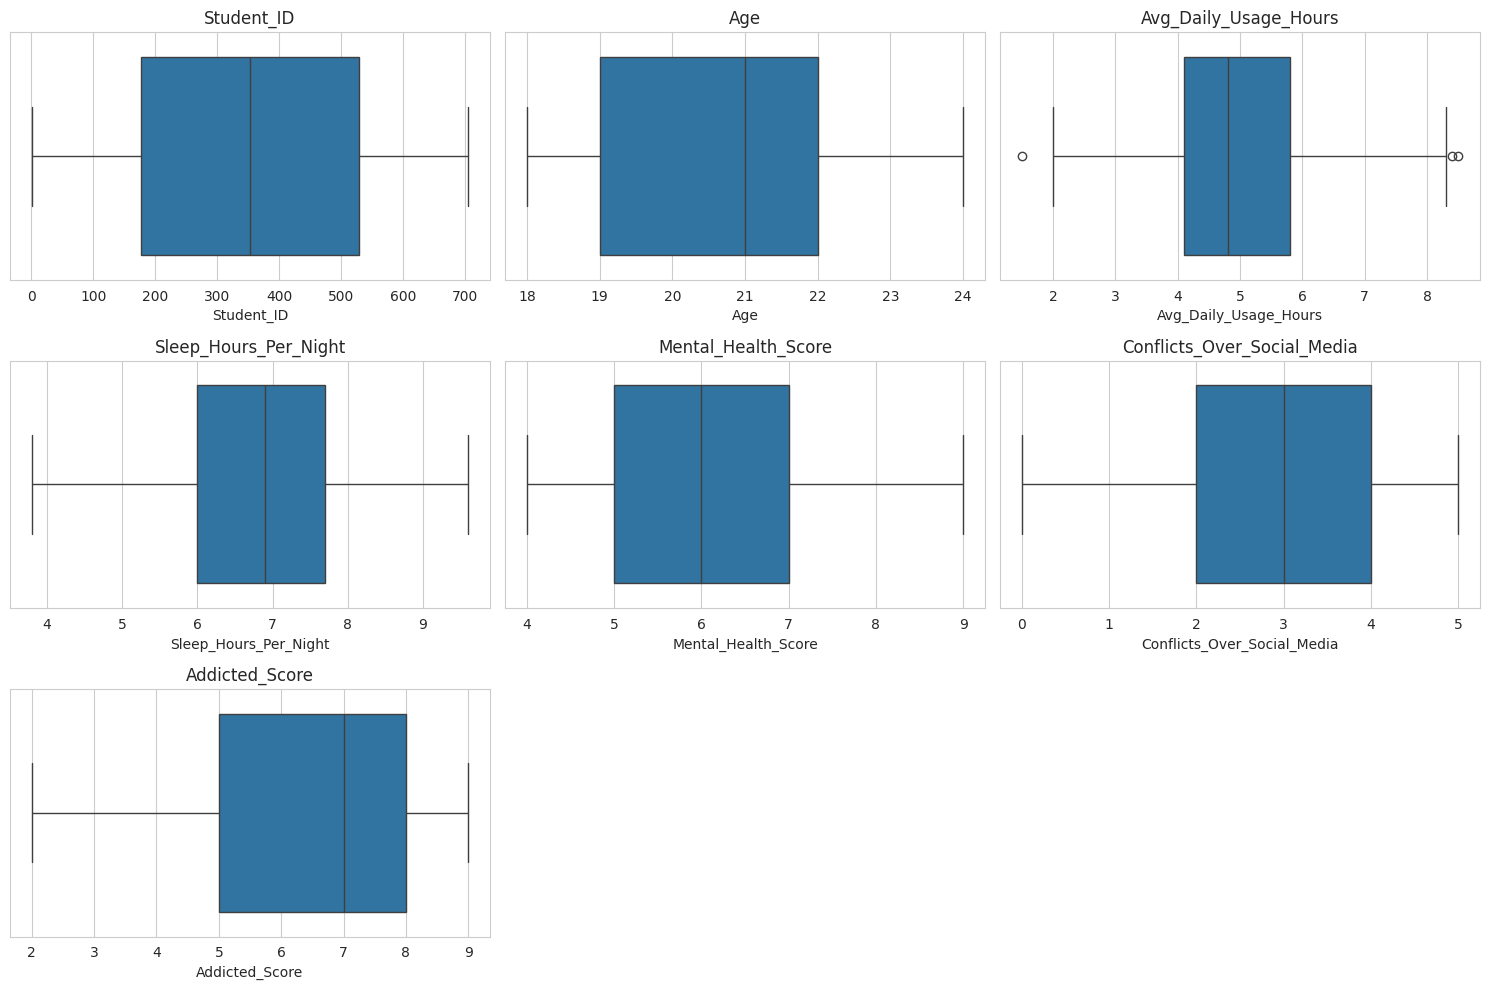

In [76]:
# Creating  boxplots for each numerical column
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [77]:
# Outlier Handling (Example: using IQR)
# You can choose a different method based on your data and analysis
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers at the bounds (example)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outliers handled by capping at IQR bounds.")

Outliers handled by capping at IQR bounds.


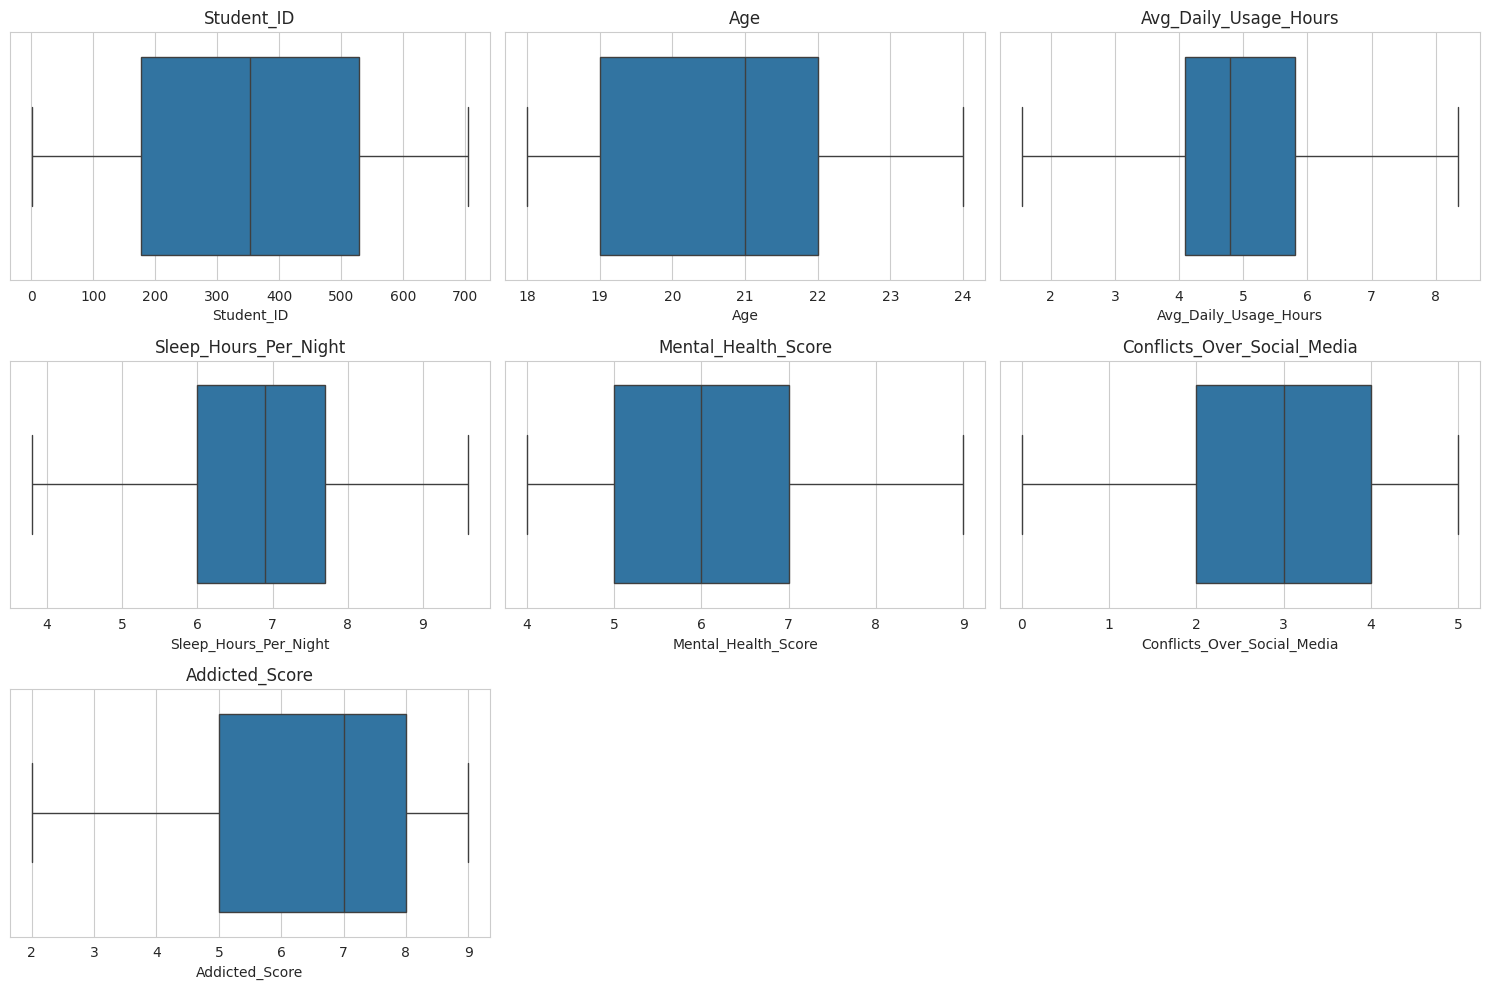

In [78]:
# Create boxplots for each numerical column after outlier handling
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [79]:
sns.set_style('whitegrid')

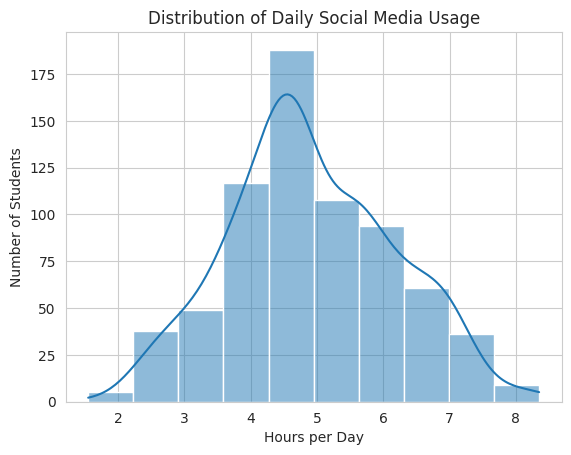

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x="Avg_Daily_Usage_Hours", bins=10, kde=True)
plt.title("Distribution of Daily Social Media Usage")
plt.xlabel("Hours per Day")
plt.ylabel("Number of Students")
plt.show()

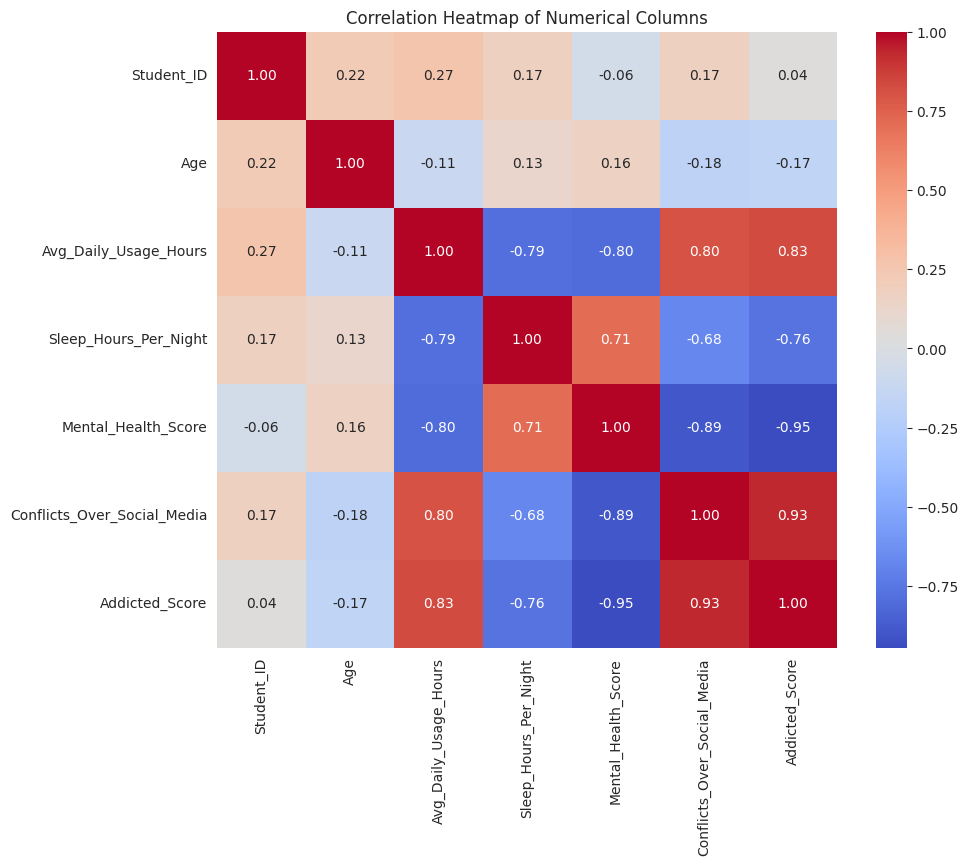

In [81]:
# Calculate the correlation matrix  the numerical variables in the dataset.
correlation_matrix = df[numerical_cols].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

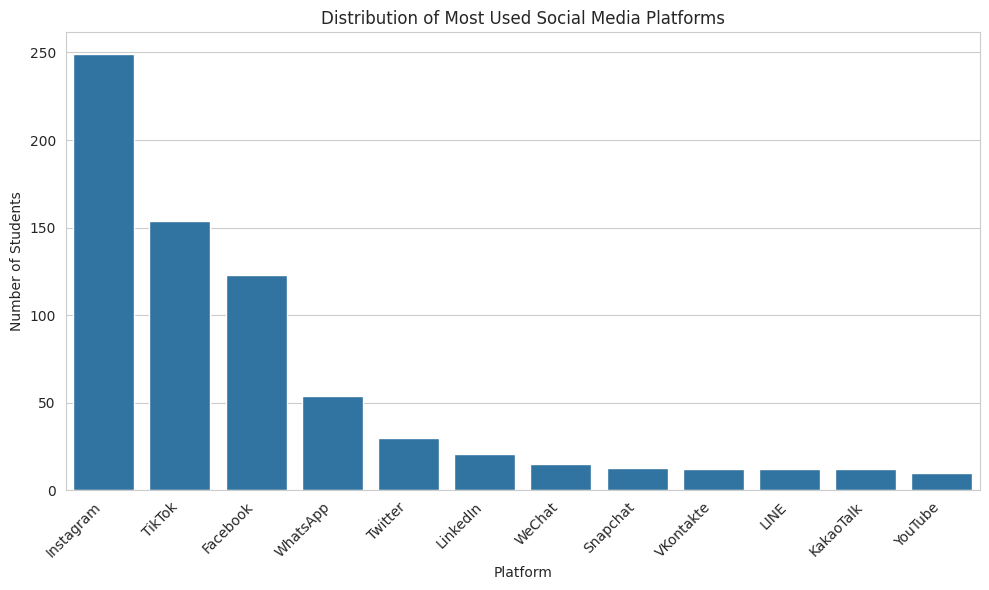

In [82]:
plt.figure(figsize=(10, 6)) # Count plots show the number of occurrences of each category in a dataset.
sns.countplot(data=df, x='Most_Used_Platform', order = df['Most_Used_Platform'].value_counts().index)
plt.title('Distribution of Most Used Social Media Platforms')
plt.xlabel('Platform')
plt.ylabel('Number of Students')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

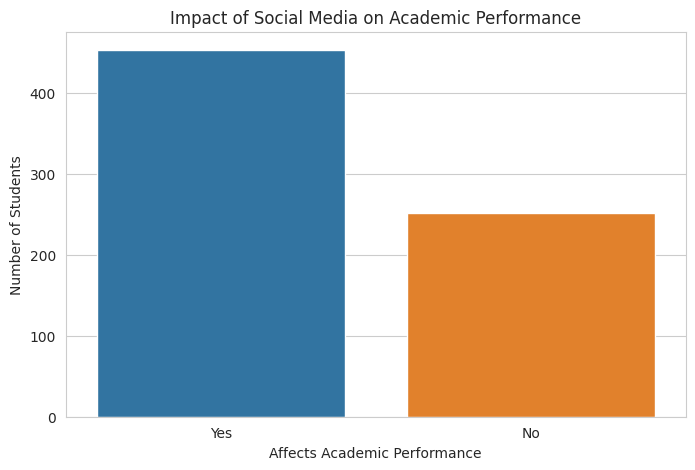

In [83]:
plt.figure(figsize=(8, 5)) # Impact of scial media on academic performance.
sns.countplot(data=df, x='Affects_Academic_Performance', hue='Affects_Academic_Performance')
plt.title('Impact of Social Media on Academic Performance')
plt.xlabel('Affects Academic Performance')
plt.ylabel('Number of Students')
plt.show()

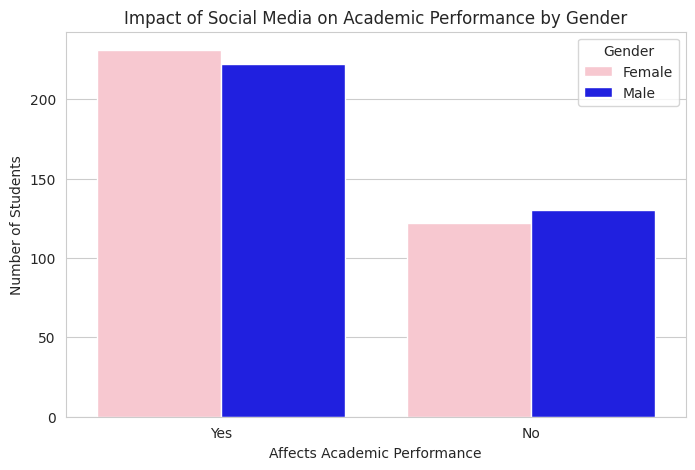

In [84]:
plt.figure(figsize=(8, 5)) # a bar chart to visualize how the impact of social media on academic performance differs between male and female students.
sns.countplot(data=df, x='Affects_Academic_Performance', hue='Gender', palette={'Male': 'blue', 'Female': 'pink'})
plt.title('Impact of Social Media on Academic Performance by Gender')
plt.xlabel('Affects Academic Performance')
plt.ylabel('Number of Students')
plt.show()

# feature engineering

In [85]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to 'Affects_Academic_Performance'
df['Affects_Academic_Performance_Encoded'] = label_encoder.fit_transform(df['Affects_Academic_Performance'])

# Apply label encoding to 'Gender'
df['Gender_Encoded'] = label_encoder.fit_transform(df['Gender'])

display(df[['Affects_Academic_Performance', 'Affects_Academic_Performance_Encoded', 'Gender', 'Gender_Encoded']].head())

,Affects_Academic_Performance,Affects_Academic_Performance_Encoded,Gender,Gender_Encoded
0,Yes,1,Female,0
1,No,0,Male,1
2,Yes,1,Female,0
3,No,0,Male,1
4,Yes,1,Male,1


In [86]:
# Identify multi-class categorical columns
multi_class_cols = ['Academic_Level', 'Country', 'Most_Used_Platform', 'Relationship_Status']

# Apply one-hot encoding to multi-class categorical columns
df_processed = pd.get_dummies(df, columns=multi_class_cols)

display(df_processed.head())

,Student_ID,Age,Gender,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Affects_Academic_Performance_Encoded,...,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Relationship_Status_Complicated,Relationship_Status_In Relationship,Relationship_Status_Single
0,1.0,19.0,Female,5.2,Yes,6.5,6.0,3.0,8.0,1,...,False,False,False,False,False,False,False,False,True,False
1,2.0,22.0,Male,2.1,No,7.5,8.0,0.0,3.0,0,...,False,False,True,False,False,False,False,False,False,True
2,3.0,20.0,Female,6.0,Yes,5.0,5.0,4.0,9.0,1,...,False,True,False,False,False,False,False,True,False,False
3,4.0,18.0,Male,3.0,No,7.0,7.0,1.0,4.0,0,...,False,False,False,False,False,False,True,False,False,True
4,5.0,21.0,Male,4.5,Yes,6.0,6.0,2.0,7.0,1,...,False,False,False,False,False,False,False,False,True,False


In [87]:
# Define addiction thresholds based on 'Addicted_Score'
# Example thresholds (these can be adjusted)
def categorize_addiction(score):
    if score <= 4:
        return 'Low Addiction'
    elif score <= 7:
        return 'Moderate Addiction'
    else:
        return 'High Addiction'

# Apply the categorization function to create a new column
df['Addiction_Level'] = df['Addicted_Score'].apply(categorize_addiction)

# Display the count of students in each addiction level
display(df['Addiction_Level'].value_counts())

,count
Addiction_Level,
Moderate Addiction,406
High Addiction,199
Low Addiction,100


In [88]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) - Assuming 'Addicted_Score' is the target
# Drop the original categorical columns with string values
X = df_processed.drop(['Addicted_Score', 'Gender', 'Affects_Academic_Performance'], axis=1)
y = df_processed['Addicted_Score']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Using 80/20 split as an example

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (564, 136)
Testing data shape: (141, 136)
Training target shape: (564,)
Testing target shape: (141,)


# 5     model building

# 1.Linear Regression

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 0.10
Root Mean Squared Error (RMSE): 0.31
R-squared (R2): 0.96


# 2.Decision Tree Regressor

In [90]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("--- Decision Tree Regressor ---")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"R-squared (R2): {r2_dt:.2f}")

--- Decision Tree Regressor ---
Mean Squared Error (MSE): 0.04
Root Mean Squared Error (RMSE): 0.21
R-squared (R2): 0.98


# 3.RandomForestRegressor

In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Regressor ---")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

--- Random Forest Regressor ---
Mean Squared Error (MSE): 0.03
Root Mean Squared Error (RMSE): 0.17
R-squared (R2): 0.99


In [92]:
!pip install xgboost

# 4.XGBRegressor

In [93]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the XGBoost Regressor model
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("--- XGBoost Regressor ---")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.2f}")

--- XGBoost Regressor ---
Mean Squared Error (MSE): 0.04
Root Mean Squared Error (RMSE): 0.21
R-squared (R2): 0.98


5.SVM

In [94]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the SVR model
svr_model = SVR()
svr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svr = svr_model.predict(X_test)

# Evaluate the model
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("--- Support Vector Machine Regressor ---")
print(f"Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.2f}")
print(f"R-squared (R2): {r2_svr:.2f}")

--- Support Vector Machine Regressor ---
Mean Squared Error (MSE): 2.73
Root Mean Squared Error (RMSE): 1.65
R-squared (R2): -0.09


/tmp/ipython-input-44145890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r2_series.index, y=r2_series.values, palette='viridis')


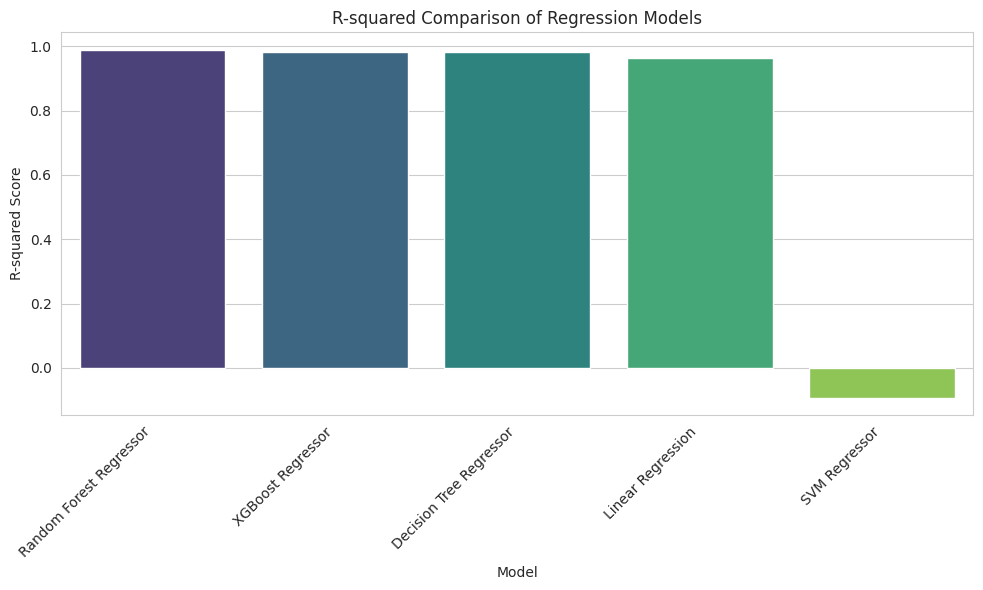

R-squared Scores:
Random Forest Regressor    0.989028
XGBoost Regressor          0.983088
Decision Tree Regressor    0.982994
Linear Regression          0.962010
SVM Regressor             -0.092520
dtype: float64


In [95]:
# Create a dictionary with the R-squared scores
r2_scores = {
    'Linear Regression': r2,
    'Decision Tree Regressor': r2_dt,
    'Random Forest Regressor': r2_rf,
    'XGBoost Regressor': r2_xgb,
    'SVM Regressor': r2_svr
}

# Create a pandas Series from the dictionary
r2_series = pd.Series(r2_scores)

# Sort the scores for better visualization
r2_series = r2_series.sort_values(ascending=False)

# Create a bar plot of the R-squared scores
plt.figure(figsize=(10, 6))
sns.barplot(x=r2_series.index, y=r2_series.values, palette='viridis')
plt.title('R-squared Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("R-squared Scores:")
print(r2_series)

## Conclusion

Based on the R-squared scores, the **Random Forest Regressor**, **XGBoost Regressor**, and **Decision Tree Regressor** models performed the best in predicting the social media addiction score. The **SVM Regressor** performed poorly on this dataset. This suggests that tree-based models are more suitable for this regression task compared to Linear Regression and SVM.

## Project Conclusion: Social Media Addiction Analysis

This project analyzed a dataset on student social media addiction using machine learning techniques.

**Key Findings and Influential Features:**

*   The exploratory data analysis revealed insights into the distribution of social media usage, the most popular platforms, and the perceived impact of social media on academic performance.
*   Based on the correlation heatmap and the performance of the regression models, features like **Avg_Daily_Usage_Hours**, **Mental_Health_Score**, and **Conflicts_Over_Social_Media** appear to be strongly correlated with the 'Addicted_Score' and are likely influential in predicting social media addiction.

**Machine Learning Performance and Recommendations:**

*   Several regression models were built to predict the 'Addicted_Score', including Linear Regression, Decision Tree Regressor, Random Forest Regressor, XGBoost Regressor, and SVM Regressor.
*   The **Random Forest Regressor**, **XGBoost Regressor**, and **Decision Tree Regressor** models demonstrated the best performance in predicting social media addiction, as indicated by their high R-squared scores. The SVM Regressor performed poorly on this dataset.
*   For future work, it is recommended to further investigate the most influential features identified and potentially explore other feature engineering techniques or more advanced machine learning models to improve prediction accuracy. Additionally, exploring classification models to predict addiction levels (e.g., Low, Moderate, High) could provide further insights.

**Save the Model**

In [96]:
import pickle

# 👇 replace rf_model with the actual name of your trained model variable
model = rf_model

# Save the model
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save the feature column order used during training
feature_columns = list(X_train.columns)
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("✅ Model and feature columns saved successfully!")


✅ Model and feature columns saved successfully!


In [97]:
import pickle
import pandas as pd

# Load the saved model
filename = 'random_forest_model.pkl'
loaded_model = pickle.load(open(filename, 'rb'))

# a prediction with new data
# the first row of the test set as new data
new_data = X_test.iloc[[0]]

# Make a prediction
predicted_score = loaded_model.predict(new_data)

print(f"Predicted Addiction Score for the new data: {predicted_score[0]:.2f}")

Predicted Addiction Score for the new data: 5.00


# Streamlit  Deployment code

In [98]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 63.7 MB/s eta 0:00:00


In [99]:
import streamlit as st
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

# Load the trained model and feature columns
try:
    with open("random_forest_model.pkl", "rb") as f:
        model = pickle.load(f)

    with open("feature_columns.pkl", "rb") as f:
        feature_columns = pickle.load(f)
    st.success("Model and feature columns loaded successfully!")
except FileNotFoundError:
    st.error("Error: Model files not found. Please make sure 'random_forest_model.pkl' and 'feature_columns.pkl' are in the same directory.")
    st.stop()

# Streamlit App Title and Description
st.title("Student Social Media Addiction Prediction")
st.write("Enter the student's details to predict their social media addiction score.")

# Create input fields for each feature
# Initialize a dictionary to store user input
user_input = {}

# Numerical features (based on df.describe() and df.info())
numerical_features = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media']
for feature in numerical_features:
    user_input[feature] = st.number_input(f"Enter {feature.replace('_', ' ')}", value=0.0)

# Categorical features (based on original df.info() and the one-hot encoded columns in feature_columns)

# Categorical features (based on original df.info() and the one-hot encoded columns in feature_columns)
# We need to identify the original categorical columns and their possible values.

# Based on the previous EDA and preprocessing steps:
categorical_features_info = {
    'Gender': ['Female', 'Male'],
    'Academic_Level': ['Undergraduate', 'Graduate', 'High School', 'Postgraduate'],
    'Country': [col.replace('Country_', '') for col in feature_columns if 'Country_' in col], # Extract countries from feature_columns
    'Most_Used_Platform': [col.replace('Most_Used_Platform_', '') for col in feature_columns if 'Most_Used_Platform_' in col], # Extract platforms
    'Relationship_Status': [col.replace('Relationship_Status_', '') for col in feature_columns if 'Relationship_Status_' in col], # Extract relationship statuses
    'Affects_Academic_Performance': ['Yes', 'No']
}

for feature, options in categorical_features_info.items():
    user_input[feature] = st.selectbox(f"Select {feature.replace('_', ' ')}", options)


# Button to trigger prediction
if st.button("Predict Addiction Score"):
    # Prepare the user input for prediction

    # Convert user input to a DataFrame
    input_df = pd.DataFrame([user_input])

    # Apply the same preprocessing steps as used for training:
    # 1. Label encoding for 'Affects_Academic_Performance' and 'Gender'
    label_encoder = LabelEncoder()
    # Fit on the original data's unique values to ensure consistency
    # We need the original unique values for these columns. Assuming they are 'Yes', 'No' for Affects_Academic_Performance
    # and 'Female', 'Male' for Gender based on the notebook's EDA.
    try:
        input_df['Affects_Academic_Performance_Encoded'] = label_encoder.fit_transform(input_df['Affects_Academic_Performance'])
        input_df['Gender_Encoded'] = label_encoder.fit_transform(input_df['Gender'])
    except ValueError as e:
        st.error(f"Error during label encoding: {e}. Please check the input values for Gender and Affects Academic Performance.")
        st.stop()


    # 2. One-hot encoding for multi-class categorical columns
    multi_class_cols = ['Academic_Level', 'Country', 'Most_Used_Platform', 'Relationship_Status']
    input_df_processed = pd.get_dummies(input_df, columns=multi_class_cols)

    # 3. Align the new data columns with the training columns
    # Create a DataFrame with all training columns initialized to 0
    aligned_input = pd.DataFrame(0, index=[0], columns=feature_columns)

    # Copy the values from the processed input DataFrame to the aligned DataFrame
    for col in input_df_processed.columns:
        if col in aligned_input.columns:
            aligned_input[col] = input_df_processed[col]



    #  a prediction
    try:
        predicted_score = model.predict(aligned_input)[0]
        st.subheader(f"Predicted Social Media Addiction Score: {predicted_score:.2f}")

        # Categorize and display addiction level
        def categorize_addiction(score):
            if score <= 4:
                return 'Low Addiction'
            elif score <= 7:
                return 'Moderate Addiction'
            else:
                return 'High Addiction'

        addiction_level = categorize_addiction(predicted_score)
        st.info(f"Addiction Level: {addiction_level}")

    except Exception as e:
        st.error(f"Error during prediction: {e}")

2025-09-04 13:05:37.640 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-04 13:05:37.971 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-09-04 13:05:37.974 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-04 13:05:37.975 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-04 13:05:37.977 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-04 13:05:37.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-04 13:05:37.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-04 13:05:37.984 Thread 'MainThread': mi

**Reasoning**:
The previous command failed because the `streamlit` library is not installed. I need to install `streamlit` using pip before I can proceed with the Streamlit script.

